<a href="https://colab.research.google.com/github/namita-code/6thSEM-ML-LAB/blob/main/LAB9kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Preview:
    sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Clustered Data (first 10 rows):
    sepal_length  sepal_width  petal_length  petal_width      species  Cluster
0           5.1          3.5           1.4          0.2  Iris-setosa        1
1           4.9          3.0           1.4          0.2  Iris-setosa        2
2           4.7          3.2           1.3          0.2  Iris-setosa        2
3           4.6          3.1           1.5          0.2  Iris-setosa        2
4           5.0          3.6           1.4          0.2  Iris-setosa        1
5           5.4          3.9           1.7          0.4  Iris-seto

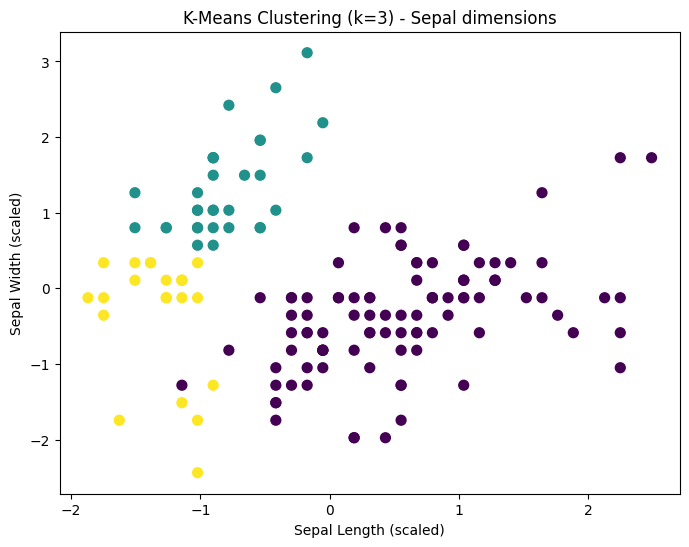

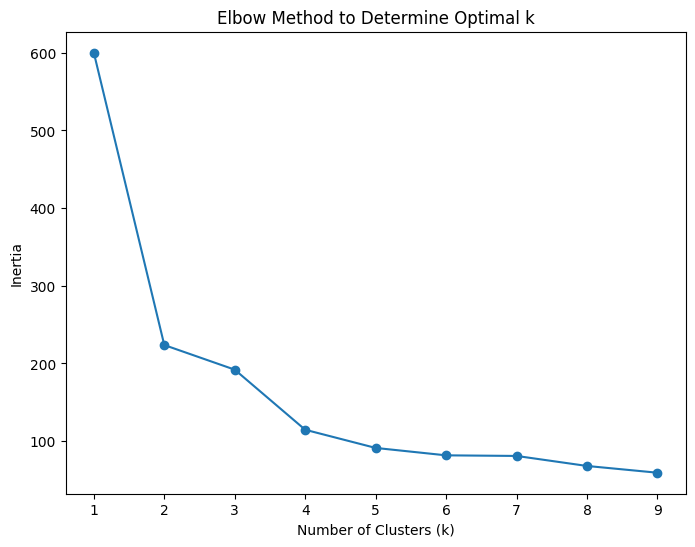

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


df = pd.read_excel("/content/iris (1).xlsx")

print("Dataset Preview:\n", df.head())


X = df.drop("species", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

df["Cluster"] = kmeans.labels_

print("\nClustered Data (first 10 rows):\n", df.head(10))


print("\nCluster Centers (scaled features):\n", kmeans.cluster_centers_)


plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans.labels_, cmap='viridis', s=50)
plt.xlabel("Sepal Length (scaled)")
plt.ylabel("Sepal Width (scaled)")
plt.title("K-Means Clustering (k=3) - Sepal dimensions")
plt.show()


inertia = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method to Determine Optimal k")
plt.show()




